In [350]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import h3
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import mapclassify
from shapely import Polygon
import shapely
import contextily
from shapely.geometry import box
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import cartogram
from PIL import Image, ImageOps

In [2]:
NOTEBOOK_PATH = Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / 'data'
MAP_DIRECTORY = NOTEBOOK_PATH / "maps"
MAP_DIRECTORY.mkdir(exist_ok=True)

In [31]:
# data: https://simplemaps.com/gis/country/ro
romania = gpd.read_file(DATA_DIRECTORY / "romania")
romania.head()

,id,name,source,geometry
0,ROSM,Satu Mare,https://simplemaps.com,"POLYGON ((23.48676 47.97111, 23.50196 47.93423..."
1,ROAR,Arad,https://simplemaps.com,"POLYGON ((21.42354 46.65823, 21.44534 46.65317..."
2,ROBH,Bihor,https://simplemaps.com,"POLYGON ((22.16761 47.59486, 22.17232 47.58986..."
3,ROTM,Timis,https://simplemaps.com,"POLYGON ((20.70437 46.16853, 20.71897 46.16457..."
4,ROMH,Mehedinti,https://simplemaps.com,"POLYGON ((23.00831 44.10045, 22.98808 44.10702..."


In [104]:
# data: https://en.wikipedia.org/wiki/List_of_Romanian_counties_by_GDP
gdp_data = pd.read_csv(DATA_DIRECTORY / "romania_gdp.csv", sep=',')
gdp_data.head()

,Rank,name,gdp_per_capita_ron,gdp_per_capita_usd
0,1,Bucharest,247744,140854
1,2,Cluj,123387,70151
2,3,Timis,107615,61184
3,4,Gorj,103088,58610
4,5,Constanta,98870,56212


<Axes: >

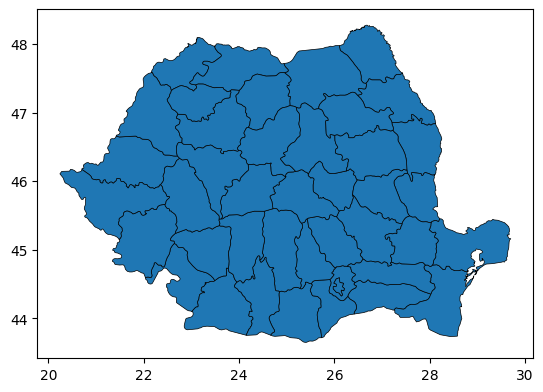

In [12]:
romania.plot(linewidth=0.5, edgecolor="black")

In [80]:
ro_data = pd.read_csv(DATA_DIRECTORY / "romania_population.csv", sep=',')
ro_data.head()

,name,abbr,status,capital,area_km2,pop_1977,pop_1992,pop_2002,pop_2011,pop_2021,pop_2025
0,Alba,ALB,Cnty,Alba Iulia,6242,409634,413919,382747,342376,325941,325106
1,Arad,ARA,Cnty,Arad,7754,512020,487617,461791,430629,410143,410085
2,Arges,ARG,Cnty,Pitești,6826,631918,681206,652625,612431,569932,561648
3,Bacau,BAC,Cnty,Bacău,6621,667791,737512,706623,616168,601387,591892
4,Bihor,BIH,Cnty,Oradea,7544,633094,638863,600246,575398,551297,556606


In [105]:
ro_gdf = romania.merge(ro_data, on="name")
ro_gdf = ro_gdf.merge(gdp_data, on="name")
ro_gdf.head()

,id,name,source,geometry,abbr,status,capital,area_km2,pop_1977,pop_1992,pop_2002,pop_2011,pop_2021,pop_2025,Rank,gdp_per_capita_ron,gdp_per_capita_usd
0,ROSM,Satu Mare,https://simplemaps.com,"POLYGON ((23.48676 47.97111, 23.50196 47.93423...",SAT,Cnty,Satu Mare,4418,393840,400789,367281,344360,330668,330296,27,56223,31965
1,ROAR,Arad,https://simplemaps.com,"POLYGON ((21.42354 46.65823, 21.44534 46.65317...",ARA,Cnty,Arad,7754,512020,487617,461791,430629,410143,410085,11,74217,42196
2,ROBH,Bihor,https://simplemaps.com,"POLYGON ((22.16761 47.59486, 22.17232 47.58986...",BIH,Cnty,Oradea,7544,633094,638863,600246,575398,551297,556606,15,66071,37564
3,ROTM,Timis,https://simplemaps.com,"POLYGON ((20.70437 46.16853, 20.71897 46.16457...",TIM,Cnty,Timișoara,8697,696884,700033,677926,683540,650533,667042,3,107615,61184
4,ROMH,Mehedinti,https://simplemaps.com,"POLYGON ((23.00831 44.10045, 22.98808 44.10702...",MEH,Cnty,Drobeta-Turnu Severin,4933,322371,332673,306732,265390,234339,229062,24,57143,32488


In [106]:
ro_gdf.count()

id                    42
name                  42
source                42
geometry              42
abbr                  42
status                42
capital               42
area_km2              42
pop_1977              42
pop_1992              42
pop_2002              42
pop_2011              42
pop_2021              42
pop_2025              42
Rank                  42
gdp_per_capita_ron    42
gdp_per_capita_usd    42
dtype: int64

In [107]:
ro_gdf = ro_gdf[['name', 'area_km2', 'pop_2021', "gdp_per_capita_usd", 'geometry']]
ro_gdf.columns = ['name', 'area', 'population', "gdp", 'geometry']
ro_gdf.head()

,name,area,population,gdp,geometry
0,Satu Mare,4418,330668,31965,"POLYGON ((23.48676 47.97111, 23.50196 47.93423..."
1,Arad,7754,410143,42196,"POLYGON ((21.42354 46.65823, 21.44534 46.65317..."
2,Bihor,7544,551297,37564,"POLYGON ((22.16761 47.59486, 22.17232 47.58986..."
3,Timis,8697,650533,61184,"POLYGON ((20.70437 46.16853, 20.71897 46.16457..."
4,Mehedinti,4933,234339,32488,"POLYGON ((23.00831 44.10045, 22.98808 44.10702..."


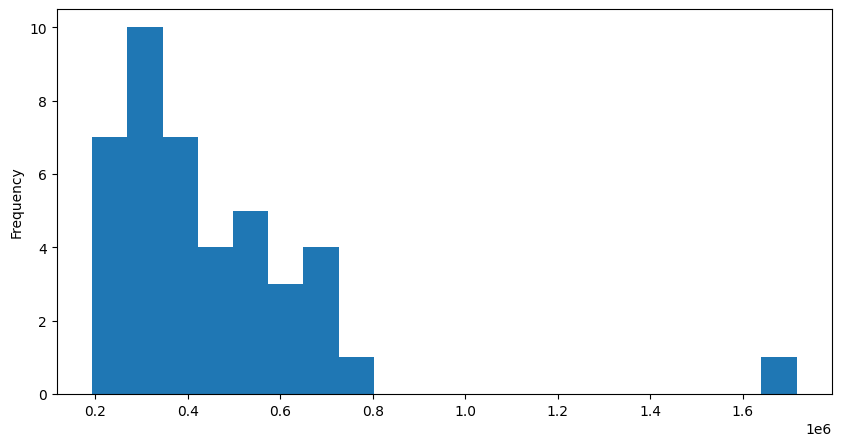

In [90]:
# Quick distribution plot for population
fig, ax = plt.subplots(figsize=(10, 5))

ro_gdf["population"].plot(
    kind="hist",
    bins=20,
    ax=ax
)

plt.show()

In [114]:
ro_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [115]:
ro_gdf = ro_gdf.to_crs("EPSG:3844") 

<Axes: >

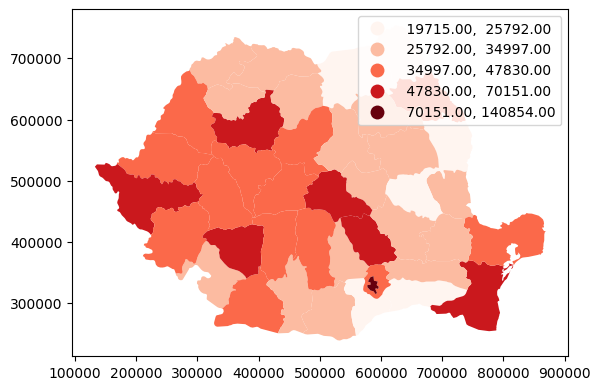

In [121]:
ro_gdf.plot(column='gdp', cmap="Reds", scheme="NaturalBreaks", legend=True)

In [ ]:
c = cartogram.Cartogram(ro_gdf, "population")
c.head()

,name,area,population,gdp,geometry
0,Satu Mare,4418,330668,31965,"POLYGON ((385074.386 703983.517, 386174.998 69..."
1,Arad,7754,410143,42196,"POLYGON ((242413.402 562856.542, 243945.284 56..."
2,Bihor,7544,551297,37564,"POLYGON ((294013.38 666683.024, 294348.789 666..."
3,Timis,8697,650533,61184,"POLYGON ((188588.483 522819.19, 189841.319 522..."
4,Mehedinti,4933,234339,32488,"POLYGON ((328785.18 317145.017, 327471.713 318..."


<Axes: >

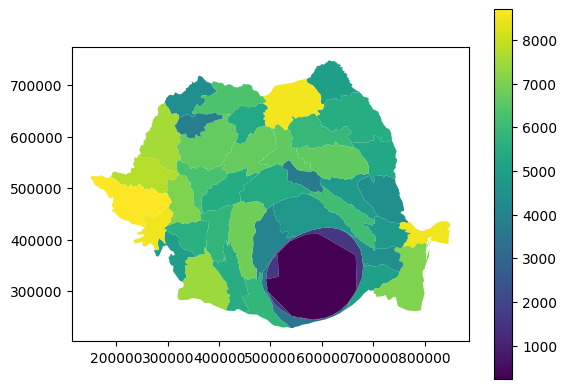

In [119]:
c.plot(column="area", cmap="viridis", legend=True)

In [140]:
reds = plt.cm.RdPu
cmap = mcolors.LinearSegmentedColormap.from_list(
    'truncated_reds',
    reds(np.linspace(0.2, 1.0, 256))
)

<Axes: >

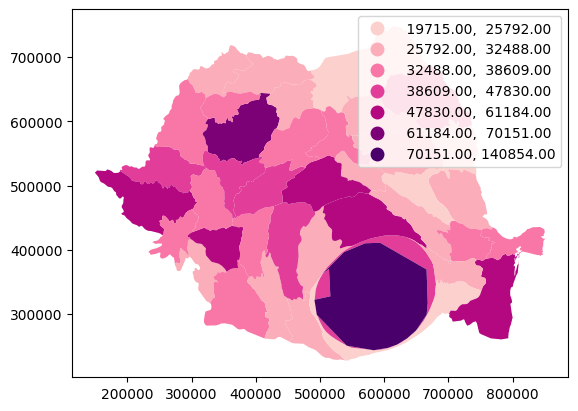

In [141]:
c.plot(column='gdp', cmap=cmap, scheme="NaturalBreaks", k=7, legend=True)

<Axes: >

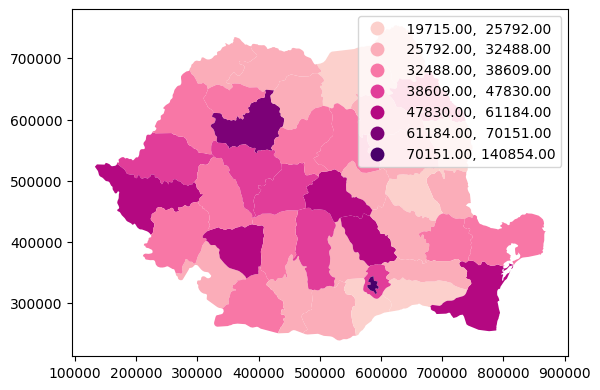

In [142]:
ro_gdf.plot(column='gdp', cmap=cmap, scheme="NaturalBreaks", k=7, legend=True)

In [252]:
classifier = mapclassify.NaturalBreaks(c['gdp'], k=7)
breaks = classifier.bins
breaks = [c['gdp'].min()] + list(breaks)

def fmt(x):
    return f"{x/1000:,.1f}k"

labels = []
for i, (lo, hi) in enumerate(zip(breaks[:-1], breaks[1:])):
    counties_in_class = c[(c['gdp'] >= lo) & (c['gdp'] < hi)]
    if len(counties_in_class) == 1:
        labels.append(fmt(hi))
    else:
        labels.append(f"{fmt(lo + 100)} - {fmt(hi)}")

colors = [cmap(i / 6) for i in range(7)]
print(labels)

['19.8k - 25.8k', '25.9k - 32.5k', '32.6k - 38.6k', '38.7k - 47.8k', '47.9k - 61.2k', '70.2k', '140.9k']


In [267]:
import matplotlib.font_manager as fm
for path in Path(NOTEBOOK_PATH / "fonts/Nunito/static").glob("*.ttf"):
    fm.fontManager.addfont(str(path))
# fm.fontManager.addfont(NOTEBOOK_PATH / "fonts/Nunito-VariableFont_wght.ttf")

for f in sorted(fm.fontManager.ttflist, key=lambda x: x.name):
    if(f.name[0] == 'J' or f.name[0] == 'N'):
      print(f.name)

Jamrul
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
Josefin Sans
NATS
NTR
Nakula
Navilu
Nimbus Mono PS
Nimbus Mono PS
Nimbus Mono PS
Nimbus Mono PS
Nimbus Roman
Nimbus Roman
Nimbus Roman
Nimbus Roman
Nimbus Sans
Nimbus Sans
Nimbus Sans
Nimbus Sans
Nimbus Sans Narrow
Nimbus Sans Narrow
Nimbus Sans Narrow
Nimbus Sans Narrow
Norasi
Norasi
Norasi
Norasi
Norasi
Norasi
Noto Mono
Noto Sans CJK JP
Noto Sans CJK JP
Noto Sans Mono
Noto Sans Mono
Noto Serif CJK JP
Noto Serif CJK JP
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito
Nunito


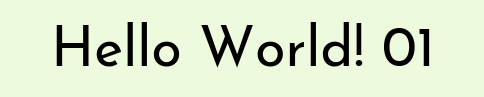

In [268]:
from matplotlib import font_manager

def print_text(text):
    fig, ax = plt.subplots(figsize=(6, 1), facecolor="#eefade")
    ax.text(0.5, 0.5, text, ha='center', va='center', size=40, fontfamily="Josefin Sans")
    ax.axis("off")
    plt.show()

print_text("Hello World! 01")

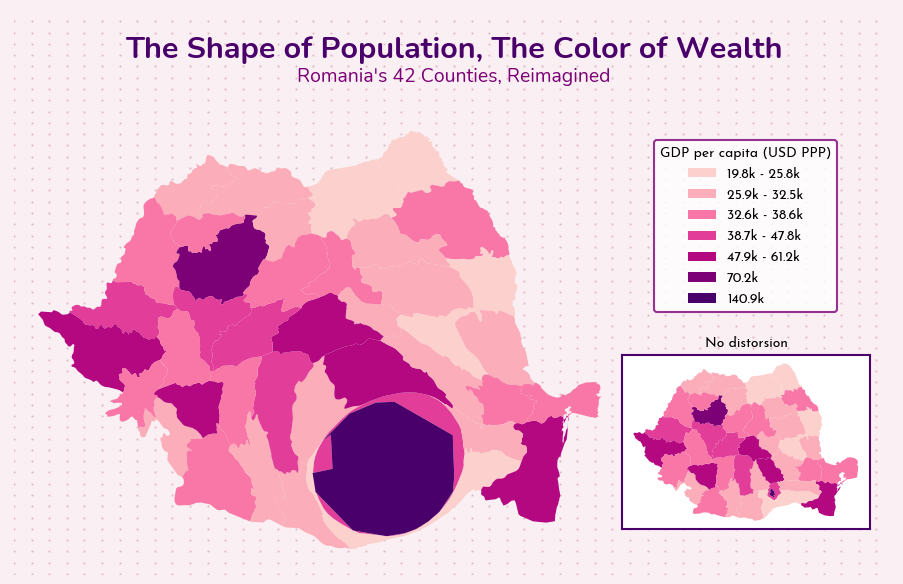

In [366]:
plt.rcParams['font.family'] = 'Josefin Sans'
fig, ax = plt.subplots(figsize=(8, 12), facecolor='#faf0f3')

ax.set_xticks([])
ax.set_yticks([])
ax.set_axis_off()

c.plot(ax=ax, column='gdp', cmap=cmap, scheme="NaturalBreaks", k=7, legend=False)

handles = [mpatches.Patch(facecolor=colors[i], label=labels[i]) for i in range(7)]

ax_inset = fig.add_axes([0.89, 0.26, 0.31, 0.3])  # [left, bottom, width, height] in figure coords
ro_gdf.plot(ax=ax_inset, column='gdp', cmap=cmap, scheme="NaturalBreaks", k=7, legend=False)
ax_inset.set_title("No distorsion", fontsize=10)
ax_inset.set_xticks([])
ax_inset.set_yticks([])

for spine in ax_inset.spines.values():
    spine.set_edgecolor(colors[-1])
    spine.set_linewidth(1.5)

ax.legend(
    handles=handles,
    title="GDP per capita (USD PPP)",
    loc='upper left',
    bbox_to_anchor = (1.028, 0.95),
    frameon=True,
    edgecolor=colors[-2]
)
ax.get_legend().get_frame().set_linewidth(1.5)

ax_bg = fig.add_axes([0.13, 0.3, 1.1, 0.47])
ax_bg.set_zorder(-1)
ax.set_zorder(1)
ax.patch.set_visible(False)

ax_bg.set_xlim([0, 1])
ax_bg.set_ylim([0, 1])

xs, ys = np.meshgrid(np.arange(0, 1, 0.02), np.arange(0, 1, 0.02))
ax_bg.scatter(xs, ys, s=0.5, color='#d0a0b0', alpha=0.5)

ax_bg.set_axis_off()
ax_bg.set_facecolor('#fdf6f8')
ax_bg.set_clip_on(True)

fig.text(0.68, 0.73, "The Shape of Population, The Color of Wealth", ha='center', fontsize=22,  color=colors[-1], fontweight='bold', fontfamily="Nunito")
fig.text(0.68, 0.71, "Romania's 42 Counties, Reimagined", ha='center', fontsize=14,  color=colors[-2], fontweight='normal', fontfamily="Nunito")

plt.savefig(MAP_DIRECTORY / "map15.png", dpi=300, bbox_inches="tight")
plt.show()

2711 1752


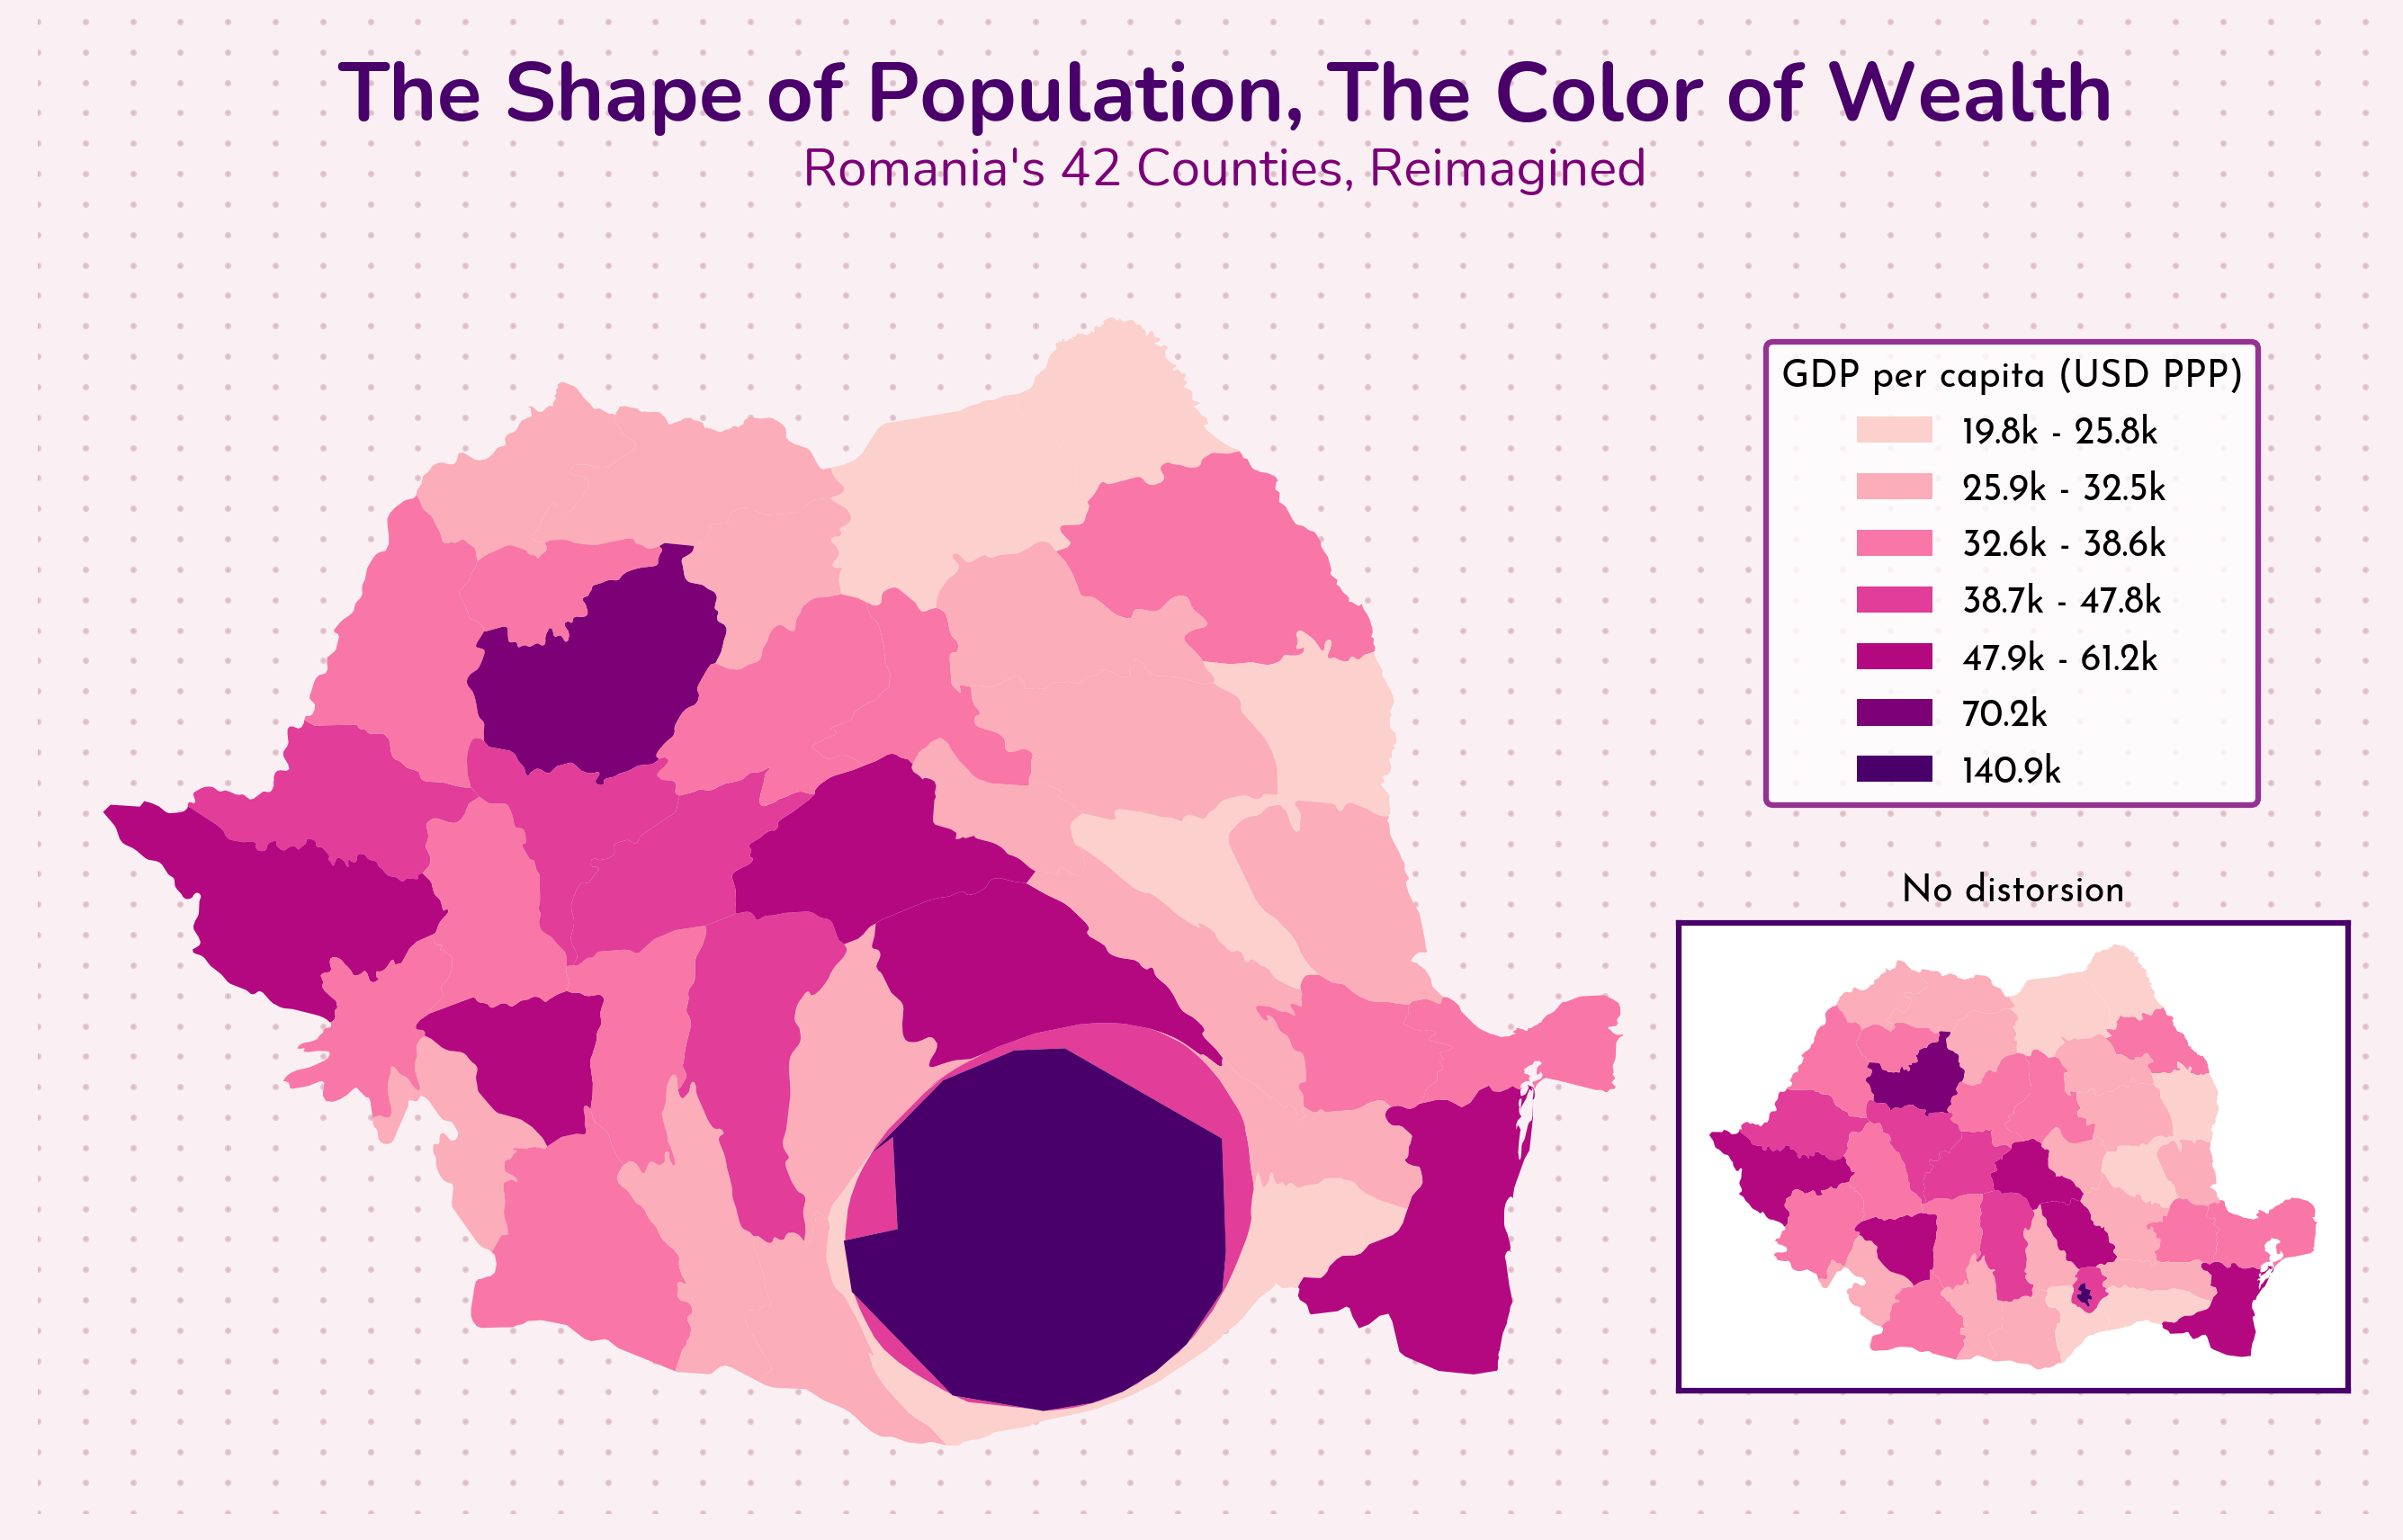

In [367]:
img = Image.open(MAP_DIRECTORY / "map15.png")
width, height = img.size
print(width, height)
crop_top = 40
crop_right = 40

cropped = img.crop((0, crop_top, width - crop_right, height))

cropped.save(MAP_DIRECTORY / "map15.png")
display(cropped)

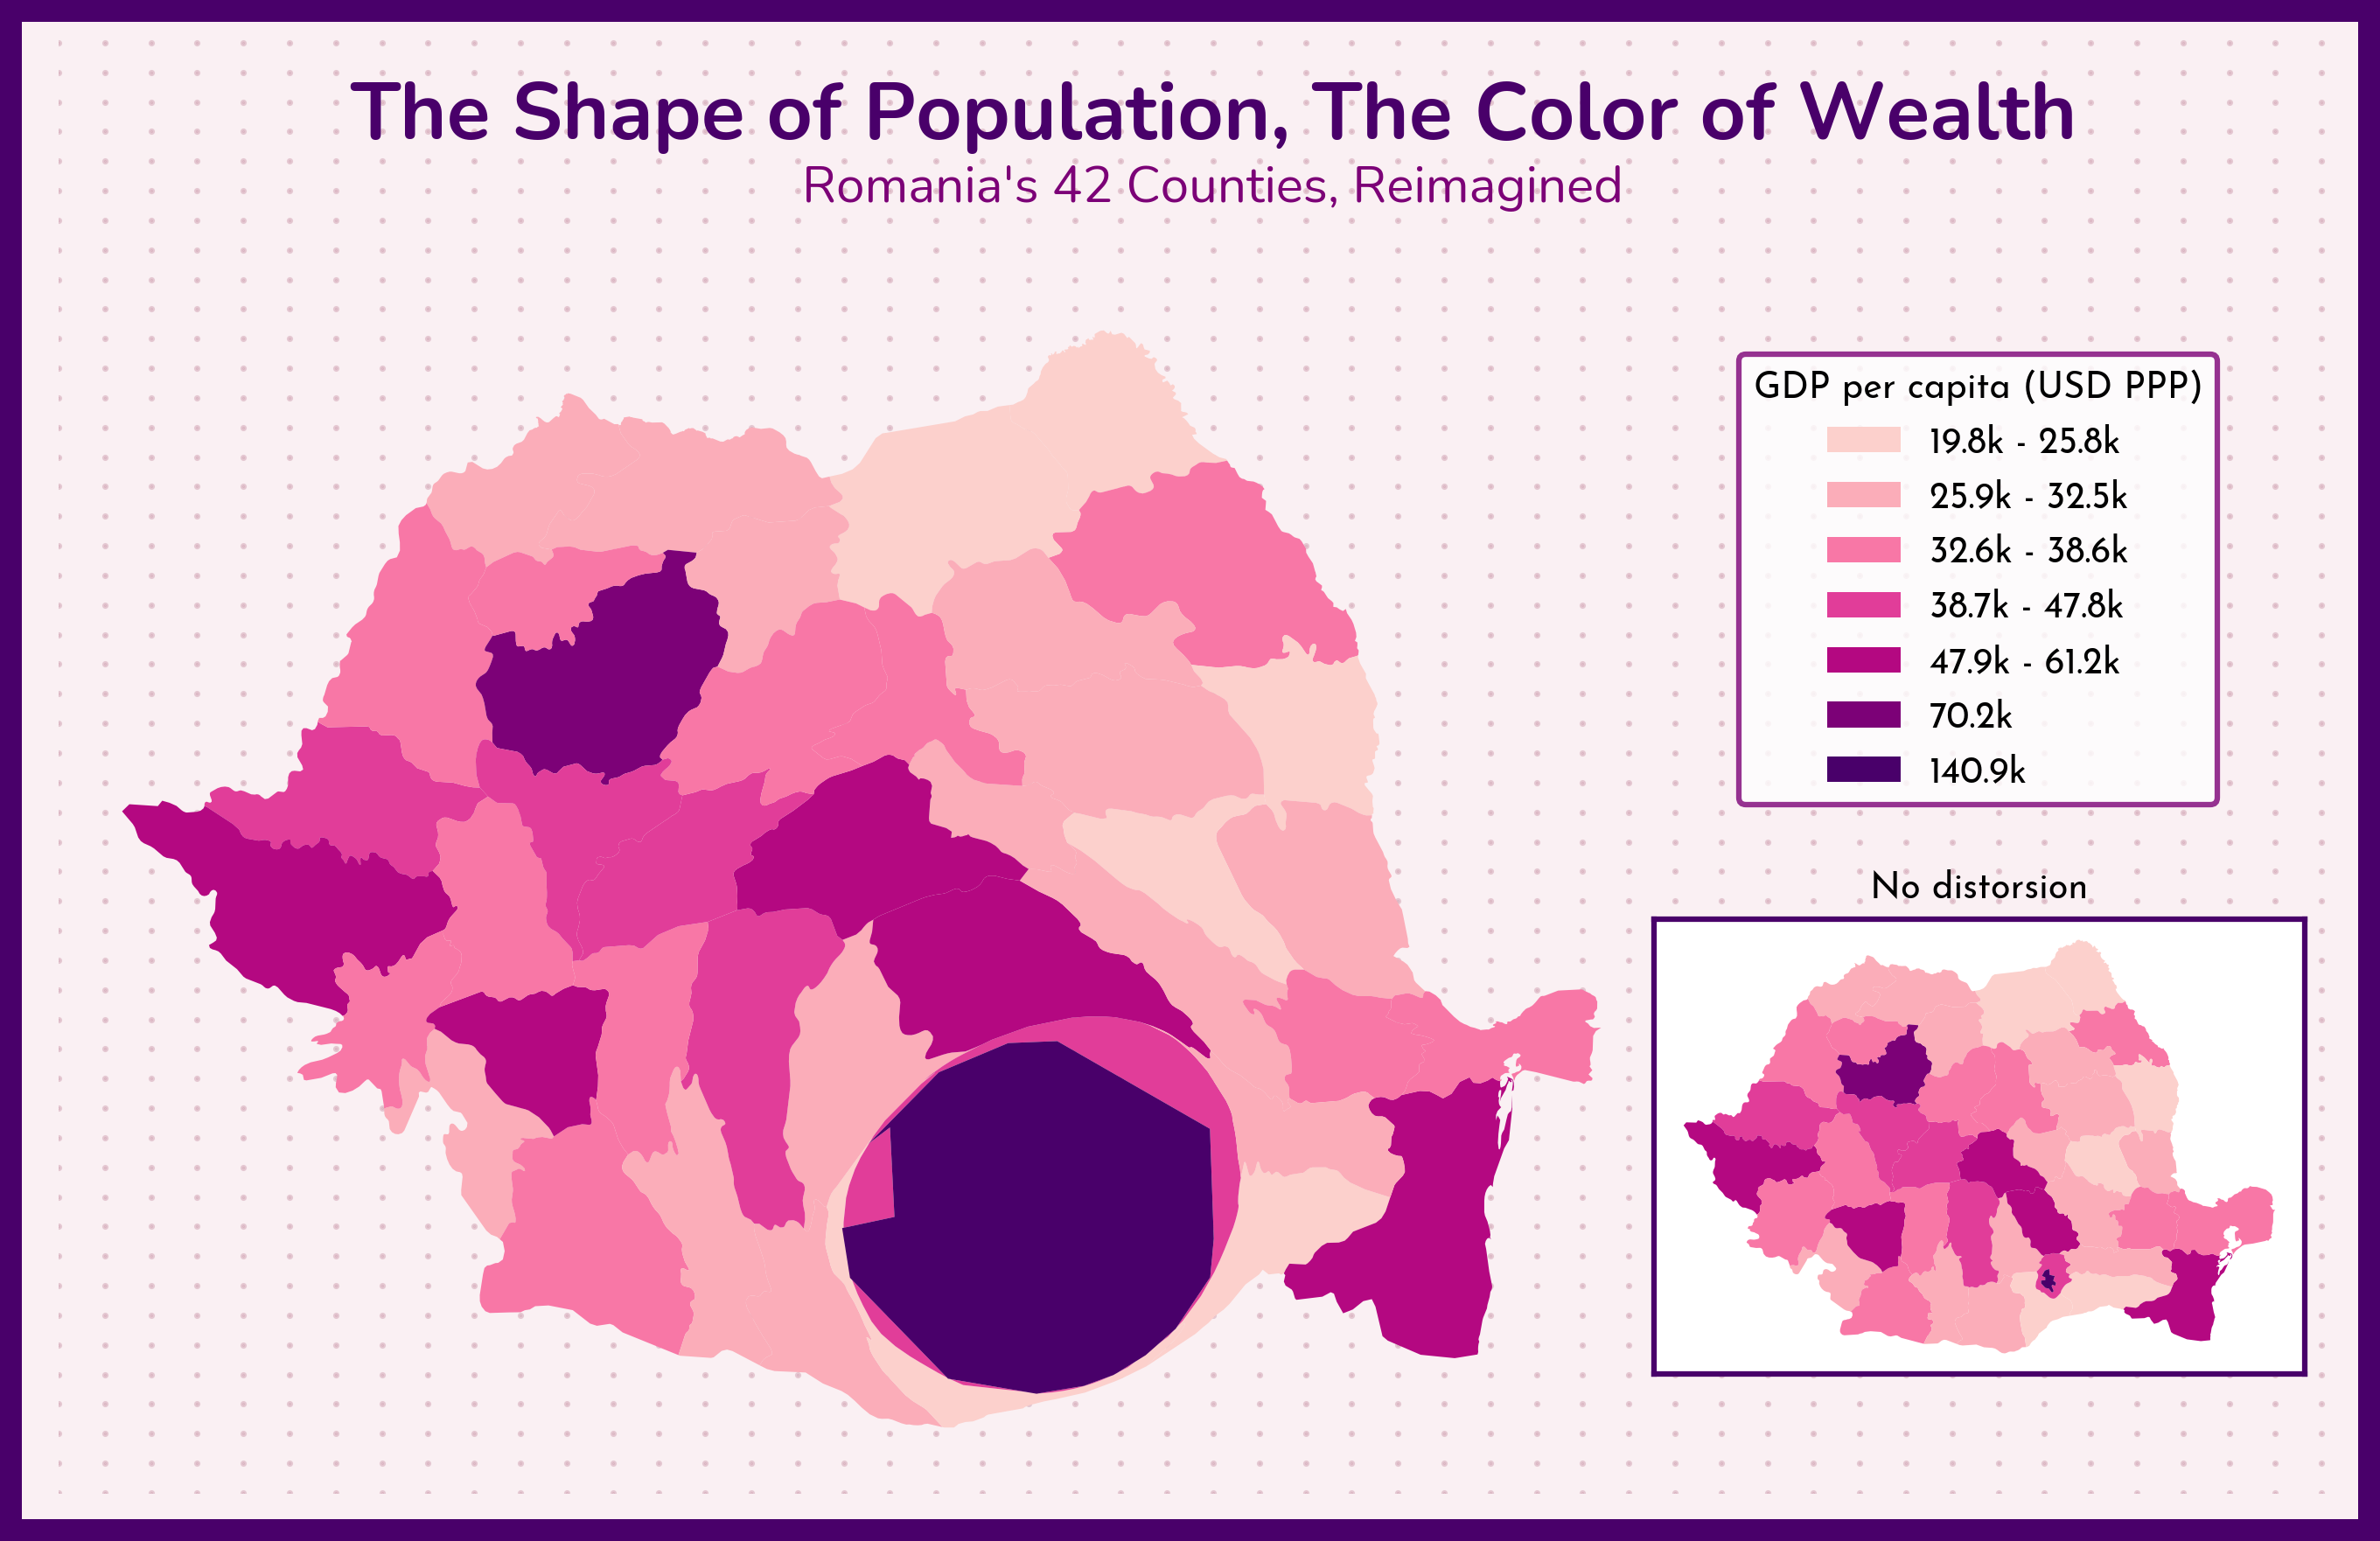

In [368]:
img = Image.open(MAP_DIRECTORY / "map15.png")
color = tuple((np.array(colors[-1][:3]) * 255).astype(int))
bordered = ImageOps.expand(img, border=25, fill=color) 
bordered.save(MAP_DIRECTORY / "map15.png")
display(bordered)